$\frac{d^2y}{dx^2}=-y^n-\frac{2}{x}\frac{dy}{dx}$   
Let's $y=y_1$ and $\frac{dy}{dx}=\frac{dy_1}{dx}=y_2$   
Therefore,   
$\frac{dy_1}{dx}=y_2$   
$\frac{dy_2}{dx}=-y_1^n-\frac{2}{x}y_2$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.integrate import solve_ivp

In [2]:
# Use serif fonts to match journal text
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5

# Tick formatting (inward-facing, all sides)
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['ytick.major.width'] = 1.2

In [3]:
def lane_emden(x, y, n):
    y1, y2 = y
    y1_val = np.maximum(y1, 0.0)  # Prevent fractional powers of negative numbers if solver overshoots the root
    dy1_dx = y2
    dy2_dx = -y1_val**n - (2 / x) * y2
    return [dy1_dx, dy2_dx]

# Event function to stop integration when the surface is reached (y = 0)
def hit_surface(x, y, n):
    return y[0]
hit_surface.terminal = True
hit_surface.direction = -1

In [4]:
# Initial Conditions
y0 = [1.0, 0.0]
x0 = 1e-6
x_max = 20.0
n = 3

In [5]:
sol = solve_ivp(lane_emden, [x0, x_max], y0, args=(n,),
                events=hit_surface, dense_output=True,
                rtol=1e-10, atol=1e-10)

In [6]:
if sol.success and len(sol.t_events[0]) > 0:
    print(f"Surface reached at x = {sol.t_events[0][0]:.5f}")

Surface reached at x = 6.89685


$\rho = \rho_c\theta^n$   
$\theta = \sqrt[n]{\frac{\rho}{\rho_c}}$   
Let's $A = -\epsilon_{max}^2\left[ \frac{d\theta}{d\epsilon} \right]_{\epsilon_{max}}$

n = 0   | Surface at x = 2.44949  | A = 4.89898
n = 1   | Surface at x = 3.14159  | A = 3.14159
n = 1.5 | Surface at x = 3.65375  | A = 2.71406
n = 2   | Surface at x = 4.35287  | A = 2.41105
n = 2.5 | Surface at x = 5.35528  | A = 2.18720
n = 3   | Surface at x = 6.89685  | A = 2.01824
n = 4   | Surface at x = 14.97155 | A = 1.79723
n = 1.4142135623730951 | Surface at x = 3.55482  | A = 2.77680


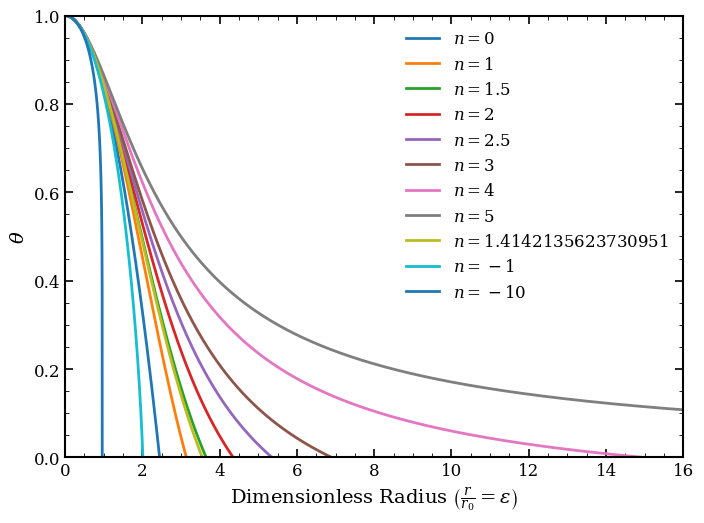

In [7]:
n_values = [0, 1, 1.5, 2, 2.5, 3, 4, 5, np.sqrt(2), -1, -10]

factor = 1.8
fig, ax = plt.subplots(figsize=(factor*4, factor*3))

for n in n_values:
    sol = solve_ivp(lane_emden, [x0, x_max], y0, args=(n,),
                    events=hit_surface, dense_output=True,
                    rtol=1e-10, atol=1e-10)
    # print(n, sol.success, sol.t_events)
    if sol.success and len(sol.t_events[0]) > 0:
        xval_max = sol.t_events[0][0]
        dy_dx_xval_max = sol.y_events[0][0][1]
        print(f"n = {n:<3} | Surface at x = {xval_max:<8.5f} | A = {-xval_max**2 * dy_dx_xval_max:.5f}")

    x = np.linspace(x0, sol.t[-1], 500)
    y = sol.sol(x)[0]
    y = np.maximum(y, 0.0)  # replace any negative values with 0.0

    ax.plot(x, y, label=f'$n = {n}$', linewidth=2)

ax.set_xlim(0, 16)
ax.set_ylim(0, 1)
ax.set_xlabel(r'Dimensionless Radius $\left( \frac{r}{r_0} = \epsilon \right)$', fontsize=14)
ax.set_ylabel(r'$\theta$', fontsize=14)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(frameon=False, fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()

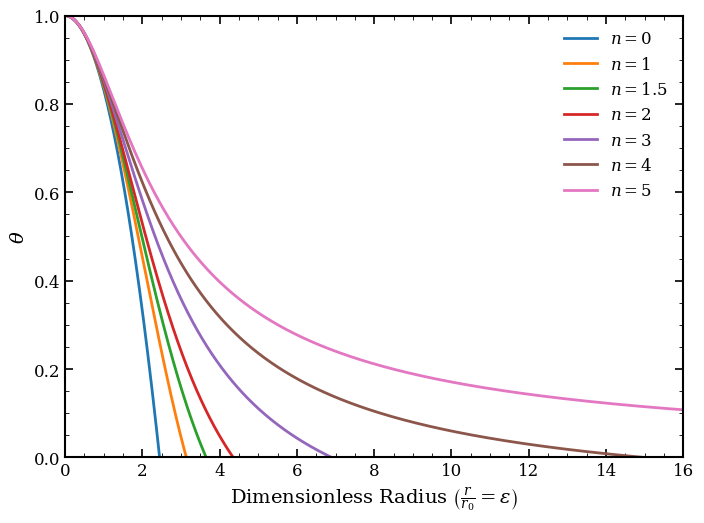

In [8]:
n_values = [0, 1, 1.5, 2, 3, 4, 5]

factor = 1.8
fig, ax = plt.subplots(figsize=(factor*4, factor*3))

for n in n_values:
    sol = solve_ivp(lane_emden, [x0, x_max], y0, args=(n,),
                    events=hit_surface, dense_output=True,
                    rtol=1e-10, atol=1e-10)

    x = np.linspace(x0, sol.t[-1], 500)
    y = sol.sol(x)[0]
    y = np.maximum(y, 0.0)  # replace any negative values with 0.0

    ax.plot(x, y, label=f'$n = {n}$', linewidth=2)

ax.set_xlim(0, 16)
ax.set_ylim(0, 1)
ax.set_xlabel(r'Dimensionless Radius $\left( \frac{r}{r_0} = \epsilon \right)$', fontsize=14)
ax.set_ylabel(r'$\theta$', fontsize=14)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(frameon=False, fontsize=12, loc='upper right')
plt.tight_layout()
plt.savefig('./IMGs/lane_emden_theta.png', bbox_inches='tight', dpi=1200)
plt.show()

Surface reached at x (n = 0) = 2.44949
Surface reached at x (n = 1) = 3.14159
Surface reached at x (n = 1.5) = 3.65375
Surface reached at x (n = 2) = 4.35287
Surface reached at x (n = 3) = 6.89685
Surface reached at x (n = 4) = 14.97155


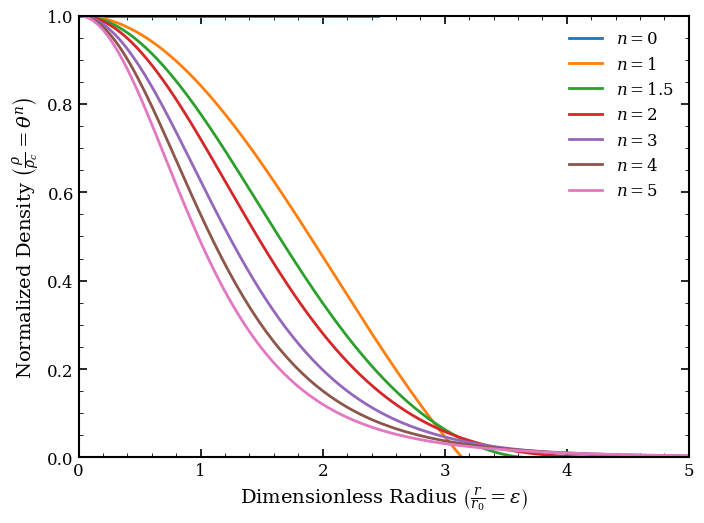

In [9]:
# Polytropic indices to plot
n_values = [0, 1, 1.5, 2, 3, 4, 5]

factor = 1.8
fig, ax = plt.subplots(figsize=(factor*4, factor*3))

for n in n_values:
    sol = solve_ivp(lane_emden, [x0, x_max], y0, args=(n,),
                    events=hit_surface, dense_output=True,
                    rtol=1e-10, atol=1e-10)
    # print(n, sol.success, sol.t_events)
    if sol.success and len(sol.t_events[0]) > 0:
        print(f"Surface reached at x (n = {n}) = {sol.t_events[0][0]:.5f}")

    x = np.linspace(x0, sol.t[-1], 500)
    y = sol.sol(x)[0]
    y = np.maximum(y, 0.0)  # replace any negative values with 0.0

    ax.plot(x, y**n, label=f'$n = {n}$', linewidth=2)

ax.set_xlim(0, 5)
ax.set_ylim(0, 1)
ax.set_xlabel(r'Dimensionless Radius $\left( \frac{r}{r_0} = \epsilon \right)$', fontsize=14)
ax.set_ylabel(r'Normalized Density $\left( \frac{\rho}{\rho_c} = \theta^n \right)$', fontsize=14)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(frameon=False, fontsize=12, loc='upper right')
plt.tight_layout()
plt.savefig('./IMGs/lane_emden_thetan.png', bbox_inches='tight', dpi=1200)
plt.show()